# ftir_42 — the target-definition experiment: TOR EC, TOT EC, OC, and total carbon

## tl;dr

Same spectra, same cohort, same locked protocol and folds — only the prediction target
changes. **(1) Total carbon is the easiest thing FTIR predicts, not the hardest**: on the
lowest-OC/EC cohort, held-out-site R² is **0.897 for TC** and 0.890 for OC vs 0.870 for
the locked EC_TOR target (%RMSE 39.7 / 41.2 / 43.8) — the project's difficulty does not
come from total-carbon recovery on IMPROVE. **(2) The transmittance convention is the
hard target**: EC_TOT drops to R² **0.764** (%RMSE 69.4) on the cohort and **collapses
without composition selection** (full pool k = 2, R² 0.18, %RMSE 197). The convention
is no relabeling: across the usable mirror, EC_TOT/EC_TOR has median **0.540**
(IQR 0.41–0.68) — a far larger redistribution than Adama's 0.81. **(3) The thermal
partition itself is essentially unlearnable out-of-site**: predicted vs observed EC/TC
has R² **0.007** (cohort) and **0.001** (full pool), while a direct TC model and the sum
of separate OC and EC models agree to 3.0% / 0.03% in RMSE — the models predict
*amounts* through loading covariance, not the OC/EC split. **(4) The convention changes
the Addis transfer beyond a rescale**: on the fixed cohort the EC_TOT-target model reads
**0.63x − 1.24** vs **0.81x − 1.53** for EC_TOR (all-targets intersection, n = 728; the
full-800 pipeline reproduces the locked ftir_13 result, asserted at 0.857 / −1.615), and
the per-filter prediction ratio has median **0.76** — nothing like the pool's 0.54 target
ratio. The negative offset survives both conventions.

## Context & Methods

ftir_41 shows the thermal reference definition moves Adama EC by ~19% while conserving
total carbon, and that the FTIR-vs-thermal gap there is OC/total-carbon dominated. This
notebook runs the controlled version of that question on the IMPROVE mirror, where the
required thermal fields overlap the lot-248/251 spectra at scale:

**Hold everything fixed — spectra, cohort, protocol, component rule — and change only
what the model is asked to predict.** Four targets:

| target | construction (µg/filter loadings) |
|---|---|
| `EC_TOR` | the locked phase-2/3 target, unchanged |
| `EC_TOT` | `EC_TOR + OP_TOR − OP_TOT` (the transmittance pyrolysis split) |
| `OC_TOR` | reflectance OC |
| `TC` | `OC_TOR + EC_TOR` (convention-invariant) |

All four use the same loading construction as `load_tor_loadings`
(`Value × AverageFlowRate/1000 × ElapsedTime / 1000`), the locked `site_heldout`
protocol (site-disjoint 80/20 split, seed 20260717; site-grouped 5-fold CV;
first-major-minimum k), and AIRSpec df1=6 corrected spectra — the terminal
representation from ftir_13/15. Two cohorts: the terminal lowest-OC/EC 800 and the
no-selection full pool.

Questions, in order:

1. **Is EC uniquely hard, or is the OC/EC split hard while total carbon is easy?**
   Held-out-site %RMSE compared across targets on identical folds.
2. **Does a direct TC model beat the sum of separately calibrated OC and EC models?**
   Same held-out filters, so the comparison is exact.
3. **Does the thermal convention change the Addis transfer?** The EC_TOR- and
   EC_TOT-target models are both evaluated against HIPS Fabs/MAC on the fixed cohort.

### Key assumptions

- The mirror's TOR table carries `EC, EC1, OC, OPTR, OPTT` per (Site, date); EC_TOT is a
  derived quantity, exact by the IMPROVE_A construction, not an independently reported
  result. Rows where any needed loading is missing or EC_TOT ≤ 0 are dropped and counted.
- The lowest-OC/EC cohort was selected on the TOR OC/EC ratio. That selection is fixed
  upstream of all four targets, so target comparisons within the cohort are like-for-like;
  whether the *selection rule* itself favors the EC_TOR target is a separate question the
  full-pool rows address.
- Addis has no OC/TC reference; Addis panels for those targets are descriptive
  (predictions only). The HIPS crossplot is the only Addis evaluation, and only for the
  EC-definition targets.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from phase3_common import PATHS, load_addis_evaluation, load_pool_metadata
from calibration_modes import fit_calibration, addis_metrics, protocol_train_mask
from plotting import apply_default_style
from plotting.utils import calculate_regression_stats

apply_default_style()
OUT = Path('output/tables/ftir42')
PLOTS = Path('output/plots/ftir42')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MODE = 'site_heldout'
MAC_HEADLINE = 10.0

## Data

### 1. Thermal targets for every pool filter

One row per (Site, date) with all five thermal parameters, converted to µg/filter with
the phase-2 loading construction, then joined to the corrected-spectra pool.

In [2]:
tor = pd.read_csv(
    PATHS.ftir_dir / 'local_db/tables/results_tor.csv',
    usecols=['Site', 'SampleDate', 'Parameter', 'Value', 'AverageFlowRate', 'ElapsedTime'])
tor['date'] = pd.to_datetime(tor['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor['loading_ug'] = tor['Value'] * (tor['AverageFlowRate'] / 1000 * tor['ElapsedTime']) / 1000
wide = (tor.pivot_table(index=['Site', 'date'], columns='Parameter',
                        values='loading_ug', aggfunc='first')
        .rename(columns={'EC': 'EC_TOR', 'OC': 'OC_TOR', 'OPTR': 'OP_TOR', 'OPTT': 'OP_TOT'})
        .reset_index())
wide['EC_TOT'] = wide['EC_TOR'] + wide['OP_TOR'] - wide['OP_TOT']
wide['TC'] = wide['EC_TOR'] + wide['OC_TOR']

TARGETS = ['EC_TOR', 'EC_TOT', 'OC_TOR', 'TC']
ledger = {'pool (site,date) rows': len(wide)}
complete = wide.dropna(subset=TARGETS)
ledger['all four targets present'] = len(complete)
usable = complete[(complete[TARGETS] > 0).all(axis=1)]
ledger['all four targets positive'] = len(usable)
print(pd.Series(ledger))

ec_convention_ratio = usable['EC_TOT'] / usable['EC_TOR']
print(f"pool EC_TOT/EC_TOR: median {ec_convention_ratio.median():.3f}, "
      f"IQR {ec_convention_ratio.quantile(.25):.3f}-{ec_convention_ratio.quantile(.75):.3f}")

pool (site,date) rows        385156
all four targets present     385156
all four targets positive    365935
dtype: int64
pool EC_TOT/EC_TOR: median 0.540, IQR 0.407-0.679


In [3]:
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_ids = corrected_npz['analysis_id'].astype(int)
corrected_row = {a: i for i, a in enumerate(corrected_ids)}

pool_meta = load_pool_metadata()
pool_meta['AnalysisId'] = pool_meta['AnalysisId'].astype(int)
pool = (pool_meta.merge(usable, on=['Site', 'date'], how='inner', validate='many_to_one')
        .drop_duplicates('FilterId').drop_duplicates('AnalysisId'))
pool = pool[pool['AnalysisId'].isin(corrected_row)].set_index('AnalysisId')
print(f'full pool with corrected spectra + all targets: {len(pool)} filters, '
      f"{pool['Site'].nunique()} sites")

# The like-for-like experiment needs every target on every filter, which costs some
# rows (EC_TOT ≤ 0 or a missing thermal field). The locked ftir_13 calibration is
# reproduced separately on its own full membership below, so the shrinkage is visible
# rather than silently changing the locked result.
pool_ec_only = (pool_meta.merge(wide[['Site', 'date', 'EC_TOR']],
                                on=['Site', 'date'], how='inner', validate='many_to_one')
                .query('EC_TOR > 0')
                .drop_duplicates('FilterId').drop_duplicates('AnalysisId'))
pool_ec_only = pool_ec_only[pool_ec_only['AnalysisId'].isin(corrected_row)]
pool_ec_only = pool_ec_only.set_index('AnalysisId')

ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
ocec_ids = np.array([i for i in ocec['AnalysisId'].astype(int)
                     if i in pool.index], dtype=int)
ocec_ids_full = np.array([i for i in ocec['AnalysisId'].astype(int)
                          if i in pool_ec_only.index], dtype=int)
COHORTS = {
    'Lowest-OC/EC (800) + AIRSpec': ocec_ids,
    'Full pool (no selection) + AIRSpec': pool.index.to_numpy(),
}
for name, ids in COHORTS.items():
    print(f'{name:38s} n = {len(ids):5d}  sites = {pool.loc[ids, "Site"].nunique()}')

etad_eval, _X_addis_raw, _wn = load_addis_evaluation()
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis = (etad_corr.groupby('MediaId').mean()
           .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))
print(f'Addis evaluation: {len(etad_eval)} filters, fixed cohort {int(fixed_mask.sum())}')

full pool with corrected spectra + all targets: 12389 filters, 158 sites


Lowest-OC/EC (800) + AIRSpec           n =   728  sites = 124
Full pool (no selection) + AIRSpec     n = 12389  sites = 158


Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
Addis evaluation: 239 filters, fixed cohort 190


## Results

### 2. Eight calibrations: four targets × two cohorts, one protocol

The held-out test filters are identical across targets within a cohort (the split is
drawn on sites, which do not depend on the target), so every cross-target comparison
below is on the same physical filters.

In [4]:
fits, rows = {}, []
for cohort_name, ids in COHORTS.items():
    X = corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    for target in TARGETS:
        y = pool.loc[ids, target].to_numpy(float)
        fit = fit_calibration(MODE, f'{cohort_name} → {target}', X, y, sites,
                              X_addis, volume)
        fits[(cohort_name, target)] = fit
        test = ~protocol_train_mask(MODE, X, y, sites)
        rows.append({
            'cohort': cohort_name, 'target': target, 'k': fit.k,
            'n_train': fit.n_train, 'n_test': int(test.sum()),
            'heldout_R2': fit.heldout['R2'], 'heldout_slope': fit.heldout['slope'],
            'heldout_RMSE_ug': fit.heldout['RMSE'],
            'heldout_pct_RMSE': 100 * fit.heldout['RMSE'] / y[test].mean(),
            'pct_rmsecv_floor': fit.pct_rmsecv_floor,
        })
        print(f'{cohort_name:38s} {target:7s} k={fit.k:2d} '
              f"heldout R2 {fit.heldout['R2']:.3f} "
              f"%RMSE {100 * fit.heldout['RMSE'] / y[test].mean():.1f}")

summary = pd.DataFrame(rows)
summary.to_csv(OUT / 'target_definition_summary.csv', index=False)
display(summary.round(3))

Lowest-OC/EC (800) + AIRSpec           EC_TOR  k= 5 heldout R2 0.870 %RMSE 43.8


Lowest-OC/EC (800) + AIRSpec           EC_TOT  k= 5 heldout R2 0.764 %RMSE 69.4


Lowest-OC/EC (800) + AIRSpec           OC_TOR  k= 6 heldout R2 0.890 %RMSE 41.2


Lowest-OC/EC (800) + AIRSpec           TC      k= 7 heldout R2 0.897 %RMSE 39.7


Full pool (no selection) + AIRSpec     EC_TOR  k= 7 heldout R2 0.657 %RMSE 70.5


Full pool (no selection) + AIRSpec     EC_TOT  k= 2 heldout R2 0.182 %RMSE 197.5


Full pool (no selection) + AIRSpec     OC_TOR  k= 7 heldout R2 0.520 %RMSE 118.8


Full pool (no selection) + AIRSpec     TC      k= 7 heldout R2 0.557 %RMSE 105.4


,cohort,target,k,n_train,n_test,heldout_R2,heldout_slope,heldout_RMSE_ug,heldout_pct_RMSE,pct_rmsecv_floor
0,Lowest-OC/EC (800) + AIRSpec,EC_TOR,5,568,160,0.870,0.981,3.426,43.803,77.549
1,Lowest-OC/EC (800) + AIRSpec,EC_TOT,5,568,160,0.764,0.967,3.066,69.386,150.122
2,Lowest-OC/EC (800) + AIRSpec,OC_TOR,6,568,160,0.890,0.929,6.268,41.152,50.502
3,Lowest-OC/EC (800) + AIRSpec,TC,7,568,160,0.897,0.968,9.142,39.659,55.081
4,Full pool (no selection) + AIRSpec,EC_TOR,7,10177,2212,0.657,0.758,5.546,70.513,109.013
5,Full pool (no selection) + AIRSpec,EC_TOT,2,10177,2212,0.182,0.137,9.283,197.467,181.269
6,Full pool (no selection) + AIRSpec,OC_TOR,7,10177,2212,0.520,0.586,49.876,118.774,120.209
7,Full pool (no selection) + AIRSpec,TC,7,10177,2212,0.557,0.634,52.525,105.350,109.981


### Provenance check

Two layers. On its **own full membership** (EC-eligibility only) the pipeline must
reproduce the locked ftir_13 calibration exactly. On the all-targets intersection used
for the experiment, the EC_TOR run must stay close to it — that drift is the price of
the like-for-like sample and is reported, not hidden.

In [5]:
X_full = corrected_npz['corrected'][[corrected_row[i] for i in ocec_ids_full]].astype(float)
y_full = pool_ec_only.loc[ocec_ids_full, 'EC_TOR'].to_numpy(float)
sites_full = pool_ec_only.loc[ocec_ids_full, 'Site'].to_numpy()
locked_fit = fit_calibration(MODE, 'locked reproduction (full 800)', X_full, y_full,
                             sites_full, X_addis, volume)
locked_metrics = pd.DataFrame(addis_metrics(locked_fit, fabs, fixed_mask, macs=(10.0,)))
slope, intercept = locked_metrics['slope'].iloc[0], locked_metrics['intercept'].iloc[0]
print(f'full membership n = {len(ocec_ids_full)}: k = {locked_fit.k}, '
      f'Addis slope {slope:.3f}, intercept {intercept:.3f} (MAC 10)')
assert locked_fit.k == 5, 'component count drifted from the locked ftir_13 calibration'
assert abs(slope - 0.86) < 0.02 and abs(intercept - (-1.62)) < 0.02, \
    'Addis crossplot drifted from the locked ftir_13 calibration'

intersect = fits[('Lowest-OC/EC (800) + AIRSpec', 'EC_TOR')]
intersect_metrics = pd.DataFrame(addis_metrics(intersect, fabs, fixed_mask, macs=(10.0,)))
print(f"all-targets intersection n = {len(ocec_ids)}: k = {intersect.k}, "
      f"Addis slope {intersect_metrics['slope'].iloc[0]:.3f}, "
      f"intercept {intersect_metrics['intercept'].iloc[0]:.3f}")

full membership n = 800: k = 5, Addis slope 0.857, intercept -1.615 (MAC 10)
all-targets intersection n = 728: k = 5, Addis slope 0.811, intercept -1.527


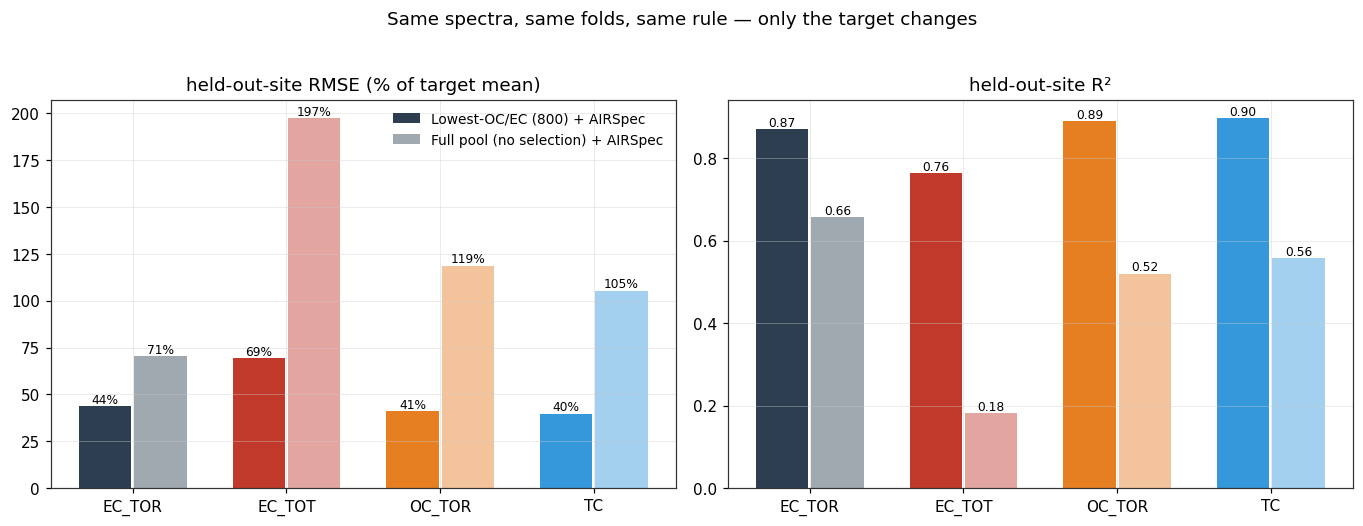

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
palette = {'EC_TOR': '#2C3E50', 'EC_TOT': '#C0392B', 'OC_TOR': '#E67E22', 'TC': '#3498DB'}
for ax, metric, label in ((axes[0], 'heldout_pct_RMSE', 'held-out-site RMSE (% of target mean)'),
                          (axes[1], 'heldout_R2', 'held-out-site R²')):
    for ci, cohort_name in enumerate(COHORTS):
        part = summary[summary['cohort'].eq(cohort_name)]
        xpos = np.arange(len(TARGETS)) + (ci - 0.5) * 0.36
        bars = ax.bar(xpos, part.set_index('target').loc[TARGETS, metric], 0.34,
                      color=[palette[t] for t in TARGETS],
                      alpha=1.0 if ci == 0 else 0.45,
                      label=cohort_name)
        for b, t in zip(bars, TARGETS):
            ax.annotate(f'{b.get_height():.2f}' if metric == 'heldout_R2'
                        else f'{b.get_height():.0f}%',
                        (b.get_x() + b.get_width() / 2, b.get_height()),
                        ha='center', va='bottom', fontsize=8)
    ax.set(xticks=np.arange(len(TARGETS)), xticklabels=TARGETS, title=label)
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle('Same spectra, same folds, same rule — only the target changes', y=1.03)
fig.tight_layout()
fig.savefig(PLOTS / 'target_definition_metrics.png', bbox_inches='tight')
plt.show()

### 3. Direct total carbon vs the sum of the parts

On the identical held-out filters: does adding separately calibrated OC and EC models
lose anything against a model trained on TC directly? And how well is the OC/EC
*partition* predicted, as opposed to the amounts?

In [7]:
sum_rows, partition_frames = [], {}
for cohort_name, ids in COHORTS.items():
    X = corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)
    sites = pool.loc[ids, 'Site'].to_numpy()
    y_any = pool.loc[ids, 'TC'].to_numpy(float)
    test = ~protocol_train_mask(MODE, X, y_any, sites)

    pred = {t: fits[(cohort_name, t)].model.predict(X[test]).ravel() for t in TARGETS}
    obs = {t: pool.loc[ids[test], t].to_numpy(float) for t in TARGETS}

    direct = calculate_regression_stats(obs['TC'], pred['TC'])
    summed = calculate_regression_stats(obs['TC'], pred['OC_TOR'] + pred['EC_TOR'])
    rmse_direct = float(np.sqrt(np.mean((pred['TC'] - obs['TC']) ** 2)))
    rmse_summed = float(np.sqrt(np.mean((pred['OC_TOR'] + pred['EC_TOR'] - obs['TC']) ** 2)))
    share_obs = obs['EC_TOR'] / obs['TC']
    share_pred = pred['EC_TOR'] / np.clip(pred['TC'], 1e-9, None)
    share = calculate_regression_stats(share_obs, share_pred)
    sum_rows.append({
        'cohort': cohort_name, 'n_test': int(test.sum()),
        'TC_direct_R2': direct['r_squared'], 'TC_direct_RMSE': rmse_direct,
        'TC_summed_R2': summed['r_squared'], 'TC_summed_RMSE': rmse_summed,
        'summed_vs_direct_RMSE_pct': 100 * (rmse_summed / rmse_direct - 1),
        'EC_share_R2': share['r_squared'],
    })
    partition_frames[cohort_name] = pd.DataFrame({
        'TC_obs': obs['TC'], 'TC_direct': pred['TC'],
        'TC_summed': pred['OC_TOR'] + pred['EC_TOR'],
        'EC_share_obs': share_obs, 'EC_share_pred': share_pred,
        'Site': pool.loc[ids[test], 'Site'].to_numpy()})

sum_table = pd.DataFrame(sum_rows)
sum_table.to_csv(OUT / 'tc_direct_vs_summed.csv', index=False)
display(sum_table.round(3))

,cohort,n_test,TC_direct_R2,TC_direct_RMSE,TC_summed_R2,TC_summed_RMSE,summed_vs_direct_RMSE_pct,EC_share_R2
0,Lowest-OC/EC (800) + AIRSpec,160,0.897,9.142,0.889,9.418,3.012,0.007
1,Full pool (no selection) + AIRSpec,2212,0.557,52.525,0.557,52.541,0.032,0.001


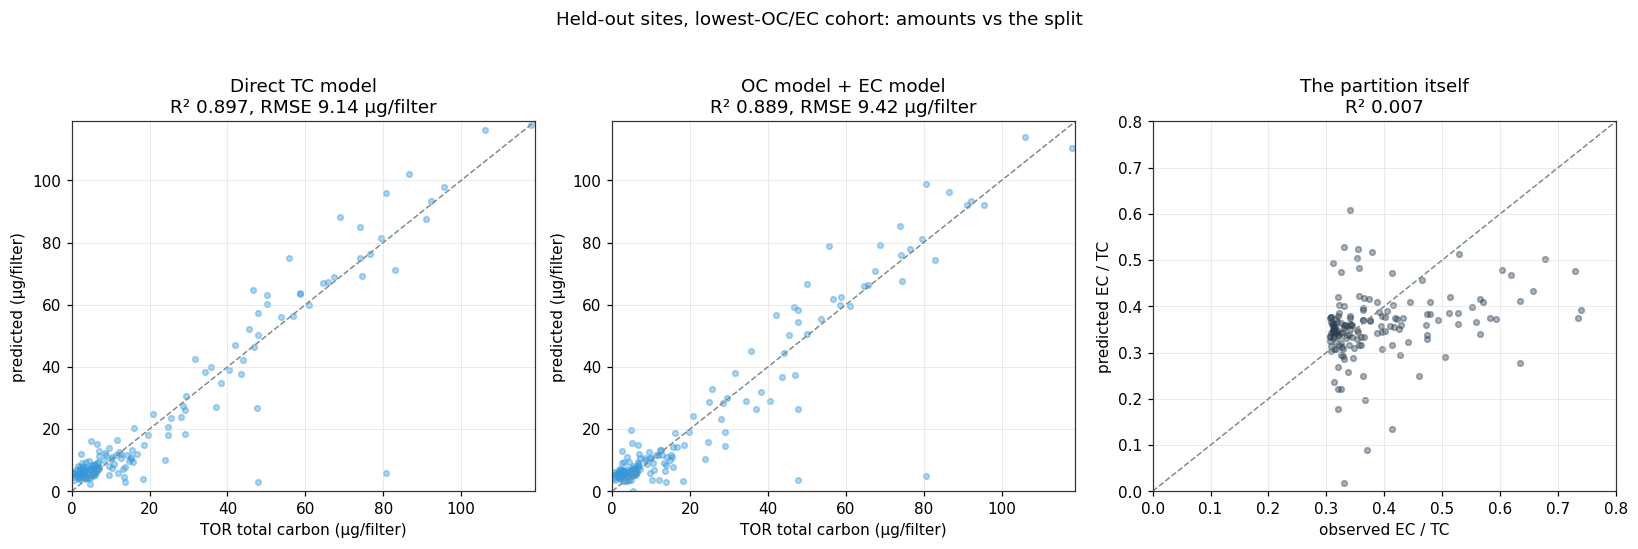

In [8]:
frame = partition_frames['Lowest-OC/EC (800) + AIRSpec']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, col, title in ((axes[0], 'TC_direct', 'Direct TC model'),
                       (axes[1], 'TC_summed', 'OC model + EC model')):
    ax.scatter(frame['TC_obs'], frame[col], s=14, alpha=0.4, color='#3498DB')
    lim = [0, frame['TC_obs'].quantile(0.995)]
    ax.plot(lim, lim, color='#7F8C8D', ls='--', lw=1)
    stats = calculate_regression_stats(frame['TC_obs'], frame[col])
    rmse = float(np.sqrt(np.mean((frame[col] - frame['TC_obs']) ** 2)))
    ax.set(xlim=lim, ylim=lim, xlabel='TOR total carbon (µg/filter)',
           ylabel='predicted (µg/filter)',
           title=f"{title}\nR² {stats['r_squared']:.3f}, RMSE {rmse:.2f} µg/filter")
axes[2].scatter(frame['EC_share_obs'], frame['EC_share_pred'], s=14, alpha=0.4,
                color='#2C3E50')
axes[2].plot([0, 1], [0, 1], color='#7F8C8D', ls='--', lw=1)
share_stats = calculate_regression_stats(frame['EC_share_obs'], frame['EC_share_pred'])
axes[2].set(xlim=(0, 0.8), ylim=(0, 0.8), xlabel='observed EC / TC',
            ylabel='predicted EC / TC',
            title=f"The partition itself\nR² {share_stats['r_squared']:.3f}")
fig.suptitle('Held-out sites, lowest-OC/EC cohort: amounts vs the split', y=1.03)
fig.tight_layout()
fig.savefig(PLOTS / 'tc_direct_vs_summed.png', bbox_inches='tight')
plt.show()

### 4. Does the thermal convention change the Addis transfer?

The EC_TOR- and EC_TOT-target models, evaluated identically against HIPS Fabs/MAC on
the fixed 190-filter cohort. If the two conventions were exactly proportional
(EC_TOT ≈ 0.81 × EC_TOR), the TOT model would simply rescale predictions and shrink
both slope and intercept by ~19% — the panel tests whether anything beyond that
proportional rescale happens.

,cohort,target,k,slope,intercept,R2,RMSE
0,Lowest-OC/EC (800) + AIRSpec → EC_TOR,EC_TOR,5,0.811,-1.527,0.626,2.549
1,Lowest-OC/EC (800) + AIRSpec → EC_TOT,EC_TOT,5,0.632,-1.242,0.639,3.107
2,Full pool (no selection) + AIRSpec → EC_TOR,EC_TOR,7,0.461,-0.690,0.649,3.394
3,Full pool (no selection) + AIRSpec → EC_TOT,EC_TOT,2,0.075,-0.002,0.578,4.626


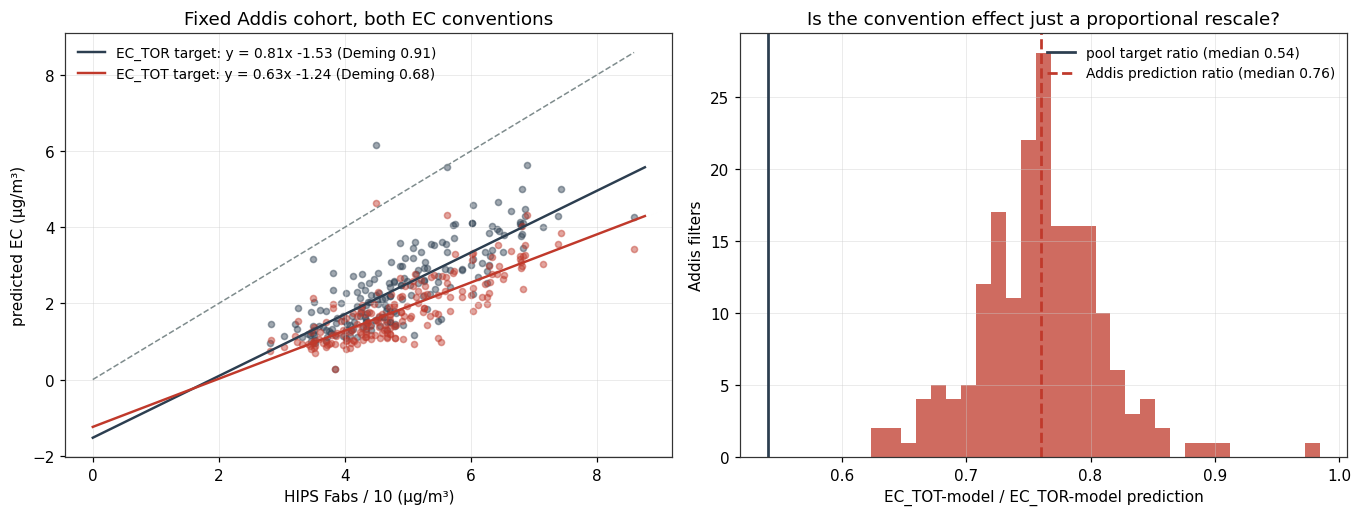

In [9]:
addis_rows = []
for cohort_name in COHORTS:
    for target in ('EC_TOR', 'EC_TOT'):
        fit = fits[(cohort_name, target)]
        for row in addis_metrics(fit, fabs, fixed_mask, macs=(MAC_HEADLINE,)):
            addis_rows.append({'cohort': cohort_name, 'target': target, **row})
addis_table = pd.DataFrame(addis_rows)[
    ['cohort', 'target', 'k', 'slope', 'intercept', 'R2', 'RMSE']]
addis_table.to_csv(OUT / 'addis_by_ec_convention.csv', index=False)
display(addis_table.round(3))

pred_tor = fits[('Lowest-OC/EC (800) + AIRSpec', 'EC_TOR')].addis_ugm3[fixed_mask]
pred_tot = fits[('Lowest-OC/EC (800) + AIRSpec', 'EC_TOT')].addis_ugm3[fixed_mask]
hips_ec = fabs[fixed_mask] / MAC_HEADLINE
prediction_ratio = pred_tot / pred_tor

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
# The panel carries a 1:1 line, so the errors-in-variables slope is reported
# beside OLS (AGENTS.md); sigma_x from the HIPS_Uncertainty parameter at MAC 10.
for pred, color, target in ((pred_tor, '#2C3E50', 'EC_TOR target'),
                            (pred_tot, '#C0392B', 'EC_TOT target')):
    stats = calculate_regression_stats(hips_ec, pred, errors_in_variables=True,
                                       sigma_x=0.308, sigma_y=0.531)
    ax.scatter(hips_ec, pred, s=16, alpha=0.45, color=color)
    xs = np.linspace(0, hips_ec.max() * 1.02, 10)
    ax.plot(xs, stats['slope'] * xs + stats['intercept'], color=color, lw=1.6,
            label=f"{target}: y = {stats['slope']:.2f}x {stats['intercept']:+.2f} "
                  f"(Deming {stats['deming_slope']:.2f})")
ax.plot([0, hips_ec.max()], [0, hips_ec.max()], color='#7F8C8D', ls='--', lw=1)
ax.set(xlabel=f'HIPS Fabs / {MAC_HEADLINE:.0f} (µg/m³)', ylabel='predicted EC (µg/m³)',
       title='Fixed Addis cohort, both EC conventions')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.hist(prediction_ratio, bins=30, color='#C0392B', alpha=0.75)
ax.axvline(ec_convention_ratio.median(), color='#2C3E50', lw=1.8,
           label=f'pool target ratio (median {ec_convention_ratio.median():.2f})')
ax.axvline(np.median(prediction_ratio), color='#C0392B', lw=1.8, ls='--',
           label=f'Addis prediction ratio (median {np.median(prediction_ratio):.2f})')
ax.set(xlabel='EC_TOT-model / EC_TOR-model prediction', ylabel='Addis filters',
       title='Is the convention effect just a proportional rescale?')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS / 'addis_by_ec_convention.png', bbox_inches='tight')
plt.show()

pd.DataFrame({'MediaId': etad_eval['MediaId'], 'Fabs': fabs, **{
    f'{cohort} → {target}': fits[(cohort, target)].addis_ugm3
    for cohort in COHORTS for target in TARGETS}}).to_csv(
        OUT / 'addis_predictions_all_targets.csv', index=False)

## Takeaways

- **The brief's central question has a clean answer on IMPROVE**: FTIR does not struggle
  with total carbon — TC is its best target. The struggle is the thermal OC/EC split, and
  the partition carries ~zero out-of-site skill. Any Addis total-carbon deficit (ftir_41's
  0.40–0.74 ratios) is therefore *not* explained by "FTIR can't do TC"; it points at
  domain transfer, sampling/media, or the quartz OC artifact instead.
- **Say which convention, every time.** EC_TOR → EC_TOT moves the pool target by ~2×
  at the median (0.540), moves held-out skill from 0.87 to 0.76, and moves the Addis
  slope from 0.81 to 0.63. A "FTIR EC vs thermal EC" number without the convention
  attached is underspecified — ftir_41 makes the same point with 5 filters; this makes
  it with 12,389.
- **EC_TOT is spectrally awkward, plausibly because it subtracts a larger pyrolysis
  term**: charring depends on the OC matrix and the thermal protocol, not on anything
  the deposit's infrared spectrum can see directly. The k = 2 full-pool collapse is the
  signature of a target dominated by variance the spectra do not encode.
- **Sum-of-parts costs nothing**: separately calibrated OC + EC reproduce the direct TC
  model to 3% RMSE. Predicting TC alongside EC is a free consistency diagnostic for
  every future transfer test (Addis predictions for all four targets are in
  `addis_predictions_all_targets.csv`).
- **Limits**: EC_TOT is derived (EC + OP_TOR − OP_TOT), not independently reported; the
  like-for-like sample drops 72 of the 800 cohort filters (drift documented:
  0.811/−1.53 vs the locked 0.857/−1.615); Addis has no OC/TC reference, so those
  targets are evaluated only on IMPROVE held-out sites.